# YOLO11n Fine-Tuning for Chess Piece Detection

## Introduction

This notebook presents the fine-tuning of **YOLO11 Nano (YOLO11n)** for chess piece object detection.

The objective is to adapt a lightweight, pretrained YOLO11n model to a custom chess piece detection task. The resulting model will be evaluated not only in terms of detection performance, but also with respect to its suitability for deployment on an embedded computing platform.

The dataset used for this experiment is the **Chess Pieces Object Detection Dataset** published by Roboflow. It contains images of chess boards with bounding-box annotations for twelve different chess piece classes:

* `white-king`
* `white-queen`
* `white-bishop`
* `white-knight`
* `white-rook`
* `white-pawn`
* `black-king`
* `black-queen`
* `black-bishop`
* `black-knight`
* `black-rook`
* `black-pawn`

The original dataset contains 292 images and 2,894 annotated objects. The images were captured from a fixed viewpoint, making the dataset representative of a controlled chessboard detection scenario.

The complete pipeline covered in this notebook consists of:

1. Dataset download
2. Dataset structure inspection
3. Image and annotation validation
4. Class distribution analysis
5. Bounding-box analysis
6. Dataset visualization
7. Dataset preparation
8. YOLO11n fine-tuning
9. Model evaluation
10. Inference on previously unseen images
11. Model export for deployment

The model is initialized from pretrained **YOLO11n** weights rather than trained from scratch. Fine-tuning allows the pretrained visual representations to be adapted to the specific appearance, scale, and spatial arrangement of chess pieces while maintaining the computational efficiency of the Nano architecture.

Particular attention is given to dataset quality and model size because the final model is intended for execution on an embedded platform. Therefore, the training pipeline is designed to preserve a lightweight model while achieving reliable chess piece detection.

The dataset is provided by Roboflow and is released under a **Public Domain** license.


## Environment Setup

The environment is configured with the libraries required for dataset handling, visualization, and YOLO11 fine-tuning.

The main framework used for object detection is **Ultralytics**, which provides the YOLO11 implementation and the training, validation, inference, and export interfaces.

Additional libraries are used for numerical operations, image processing, dataset analysis, and visualization.

The environment is also inspected before starting the experiment to verify the installed versions and the availability of hardware acceleration.


In [ ]:
%pip install -q ultralytics pandas matplotlib seaborn pillow pyyaml roboflow

In [2]:
import sys
import platform

import numpy as np

import torch
import ultralytics

In [3]:
print("=" * 60)
print("Environment Information")
print("=" * 60)

print(f"Python        : {sys.version.split()[0]}")
print(f"Platform      : {platform.platform()}")
print(f"PyTorch       : {torch.__version__}")
print(f"Ultralytics  : {ultralytics.__version__}")

print(f"\nCUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version  : {torch.version.cuda}")
    print(f"GPU           : {torch.cuda.get_device_name(0)}")
else:
    print("GPU           : CPU")

Environment Information
Python        : 3.12.3
Platform      : Linux-7.0.0-30-generic-x86_64-with-glibc2.39
PyTorch       : 2.13.0+cu130
Ultralytics  : 8.4.131

CUDA available: True
CUDA version  : 13.0
GPU           : NVIDIA GeForce RTX 5090


In [4]:
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Random seed set to: {SEED}")

Random seed set to: 42


## Dataset Download

The chess piece dataset is downloaded directly from Roboflow in YOLO format.

The dataset is available at:

https://public.roboflow.com/object-detection/chess-full

The download URL is generated by Roboflow from the dataset export interface. The **YOLO11** format should be selected when generating the download code.

The generated archive contains the images, YOLO-format annotations, dataset splits, and the `data.yaml` configuration file required by Ultralytics.

The dataset is extracted into the local `datasets/chess` directory. The exact directory structure is inspected after extraction before proceeding with dataset analysis.


In [7]:
from pathlib import Path

DATASET_DIR = Path("datasets/chess")
DATASET_DIR.mkdir(parents=True, exist_ok=True)

ZIP_PATH = DATASET_DIR.parent / "chess.zip"

print(f"Dataset directory: {DATASET_DIR.resolve()}")

Dataset directory: /tmp/pycharm_project_49c0ced5/datasets/chess


In [8]:
print("Downloading dataset...")

# insert your curl here

print("Download completed.")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   905  100   905    0     0   2996      0 --:--:-- --:--:-- --:--:--  2996
100 77.8M  100 77.8M    0     0  17.7M      0  0:00:04  0:00:04 --:--:-- 22.9M
Download completed.


In [9]:
import zipfile

print("Extracting dataset...")

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(DATASET_DIR)

print("Extraction completed.")

ZIP_PATH.unlink()

print("Temporary archive removed.")

Extracting dataset...
Extraction completed.
Temporary archive removed.


In [ ]:
print("=" * 60)
print("Dataset Structure")
print("=" * 60)

for path in sorted(DATASET_DIR.rglob("*")):
    relative_path = path.relative_to(DATASET_DIR)

    if path.is_dir():
        print(f"[DIR]  {relative_path}/")
    else:
        print(f"[FILE] {relative_path}")

## Dataset Inspection

Before preparing the dataset for training, its structure and contents are inspected programmatically.

The inspection verifies the number of images and annotations in each split, checks the correspondence between images and label files, analyzes the available object classes, and examines the distribution of annotated objects.

Image dimensions and bounding-box properties are also analyzed to identify potential dataset inconsistencies and understand the characteristics of the detection task.

The inspection is performed before any modification of the dataset so that potential annotation or data-quality issues can be identified before training.


In [14]:
from pathlib import Path

DATASET_DIR = Path("datasets/chess")

TRAIN_IMAGES_DIR = DATASET_DIR / "train" / "images"
TRAIN_LABELS_DIR = DATASET_DIR / "train" / "labels"

TEST_IMAGES_DIR = DATASET_DIR / "test" / "images"
TEST_LABELS_DIR = DATASET_DIR / "test" / "labels"

print("=" * 60)
print("Dataset Paths")
print("=" * 60)

print(f"Dataset      : {DATASET_DIR.resolve()}")
print(f"Train images : {TRAIN_IMAGES_DIR}")
print(f"Train labels : {TRAIN_LABELS_DIR}")
print(f"Test images  : {TEST_IMAGES_DIR}")
print(f"Test labels  : {TEST_LABELS_DIR}")

Dataset Paths
Dataset      : /tmp/pycharm_project_49c0ced5/datasets/chess
Train images : datasets/chess/train/images
Train labels : datasets/chess/train/labels
Test images  : datasets/chess/test/images
Test labels  : datasets/chess/test/labels


In [15]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

train_images = [
    path for path in TRAIN_IMAGES_DIR.iterdir()
    if path.suffix.lower() in IMAGE_EXTENSIONS
]

test_images = [
    path for path in TEST_IMAGES_DIR.iterdir()
    if path.suffix.lower() in IMAGE_EXTENSIONS
]

train_labels = list(TRAIN_LABELS_DIR.glob("*.txt"))
test_labels = list(TEST_LABELS_DIR.glob("*.txt"))

print("=" * 60)
print("Dataset Statistics")
print("=" * 60)

print(f"Training images : {len(train_images)}")
print(f"Training labels : {len(train_labels)}")
print(f"Test images     : {len(test_images)}")
print(f"Test labels     : {len(test_labels)}")

Dataset Statistics
Training images : 202
Training labels : 202
Test images     : 29
Test labels     : 29


### Image-Annotation Correspondence

Each image is expected to have a corresponding YOLO annotation file with the same filename stem.

The correspondence between images and annotation files is verified separately for the training and test splits.

Images without annotations and annotations without a corresponding image are reported as potential dataset inconsistencies.


In [16]:
def check_image_label_correspondence(images_dir, labels_dir):
    """Check whether every image has a corresponding label file."""

    image_stems = {
        path.stem
        for path in images_dir.iterdir()
        if path.suffix.lower() in IMAGE_EXTENSIONS
    }

    label_stems = {
        path.stem
        for path in labels_dir.glob("*.txt")
    }

    images_without_labels = sorted(image_stems - label_stems)
    labels_without_images = sorted(label_stems - image_stems)

    return images_without_labels, labels_without_images


train_missing_labels, train_missing_images = check_image_label_correspondence(
    TRAIN_IMAGES_DIR,
    TRAIN_LABELS_DIR
)

test_missing_labels, test_missing_images = check_image_label_correspondence(
    TEST_IMAGES_DIR,
    TEST_LABELS_DIR
)

In [17]:
print("=" * 60)
print("Image-Annotation Correspondence")
print("=" * 60)

print("\nTraining set:")
print(f"Images without labels      : {len(train_missing_labels)}")
print(f"Labels without images      : {len(train_missing_images)}")

print("\nTest set:")
print(f"Images without labels      : {len(test_missing_labels)}")
print(f"Labels without images      : {len(test_missing_images)}")

if train_missing_labels:
    print("\nTraining images without labels:")
    print(train_missing_labels)

if train_missing_images:
    print("\nTraining labels without images:")
    print(train_missing_images)

if test_missing_labels:
    print("\nTest images without labels:")
    print(test_missing_labels)

if test_missing_images:
    print("\nTest labels without images:")
    print(test_missing_images)

Image-Annotation Correspondence

Training set:
Images without labels      : 0
Labels without images      : 0

Test set:
Images without labels      : 0
Labels without images      : 0


### Dataset Configuration

The `data.yaml` file contains the configuration required by Ultralytics to load the dataset.

Its contents are inspected to verify the training and test paths, the number of object classes, and the class names.

The configuration is also checked for consistency between the declared number of classes and the provided class names.


In [20]:
import yaml

DATA_YAML = DATASET_DIR / "data.yaml"

with open(DATA_YAML, "r") as file:
    data_config = yaml.safe_load(file)

class_names = data_config.get("names", {})
num_classes = data_config.get("nc")

if isinstance(class_names, dict):
    class_names = list(class_names.values())

print("=" * 60)
print("Configuration Validation")
print("=" * 60)

print(f"Number of classes declared : {num_classes}")
print(f"Number of class names      : {len(class_names)}")

print("\nClasses:")
for class_id, class_name in enumerate(class_names):
    print(f"{class_id:2d}: {class_name}")

assert num_classes == len(class_names), (
    "Mismatch between 'nc' and the number of class names."
)

print("\nConfiguration is consistent.")


Configuration Validation
Number of classes declared : 13
Number of class names      : 13

Classes:
 0: bishop
 1: black-bishop
 2: black-king
 3: black-knight
 4: black-pawn
 5: black-queen
 6: black-rook
 7: white-bishop
 8: white-king
 9: white-knight
10: white-pawn
11: white-queen
12: white-rook

Configuration is consistent.


### Annotation Validation

The YOLO annotation files are inspected to verify that all bounding-box annotations follow the expected format.

Each annotation is expected to contain five values:

```text
class_id x_center y_center width height
```

The class identifier must correspond to one of the classes defined in `data.yaml`, while the normalized bounding-box coordinates must remain within the `[0, 1]` range.

Invalid or malformed annotations are reported before proceeding with training.


In [21]:
def validate_annotations(labels_dir, num_classes):
    """
    Validate YOLO-format annotation files.

    Expected format:
        class_id x_center y_center width height
    """

    invalid_annotations = []
    total_annotations = 0

    for label_path in sorted(labels_dir.glob("*.txt")):

        with open(label_path, "r") as file:
            lines = file.readlines()

        for line_number, line in enumerate(lines, start=1):

            line = line.strip()

            if not line:
                continue

            parts = line.split()

            if len(parts) != 5:
                invalid_annotations.append({
                    "file": str(label_path),
                    "line": line_number,
                    "reason": "Expected 5 values",
                    "content": line
                })
                continue

            try:
                class_id = int(parts[0])
                coordinates = [float(value) for value in parts[1:]]
            except ValueError:
                invalid_annotations.append({
                    "file": str(label_path),
                    "line": line_number,
                    "reason": "Non-numeric value",
                    "content": line
                })
                continue

            x_center, y_center, width, height = coordinates

            if not 0 <= class_id < num_classes:
                invalid_annotations.append({
                    "file": str(label_path),
                    "line": line_number,
                    "reason": "Invalid class ID",
                    "content": line
                })
                continue

            if not all(0 <= value <= 1 for value in coordinates):
                invalid_annotations.append({
                    "file": str(label_path),
                    "line": line_number,
                    "reason": "Coordinates outside [0, 1]",
                    "content": line
                })
                continue

            if width <= 0 or height <= 0:
                invalid_annotations.append({
                    "file": str(label_path),
                    "line": line_number,
                    "reason": "Non-positive bounding-box dimensions",
                    "content": line
                })
                continue

            total_annotations += 1

    return total_annotations, invalid_annotations

In [22]:
train_annotation_count, train_invalid = validate_annotations(
    TRAIN_LABELS_DIR,
    num_classes
)

test_annotation_count, test_invalid = validate_annotations(
    TEST_LABELS_DIR,
    num_classes
)

print("=" * 60)
print("Annotation Validation")
print("=" * 60)

print(f"Valid training annotations : {train_annotation_count}")
print(f"Invalid training entries   : {len(train_invalid)}")

print(f"\nValid test annotations     : {test_annotation_count}")
print(f"Invalid test entries       : {len(test_invalid)}")

Annotation Validation
Valid training annotations : 2108
Invalid training entries   : 0

Valid test annotations     : 376
Invalid test entries       : 0


### Class Distribution

The distribution of annotated objects across the different chess piece classes is analyzed separately for the training and test sets.

This analysis provides an overview of the balance between classes and identifies potential class-imbalance issues that may influence the fine-tuning process.


In [23]:
from collections import Counter

def get_class_distribution(labels_dir):
    """Count annotated objects for each class."""

    class_counter = Counter()

    for label_path in labels_dir.glob("*.txt"):

        with open(label_path, "r") as file:
            for line in file:

                parts = line.strip().split()

                if len(parts) == 5:
                    class_id = int(parts[0])
                    class_counter[class_id] += 1

    return class_counter


train_class_distribution = get_class_distribution(TRAIN_LABELS_DIR)
test_class_distribution = get_class_distribution(TEST_LABELS_DIR)

print("=" * 60)
print("Class Distribution")
print("=" * 60)

for class_id, class_name in enumerate(class_names):

    train_count = train_class_distribution.get(class_id, 0)
    test_count = test_class_distribution.get(class_id, 0)

    print(
        f"{class_id:2d} | "
        f"{class_name:<15} | "
        f"Train: {train_count:4d} | "
        f"Test: {test_count:4d}"
    )

Class Distribution
 0 | bishop          | Train:    1 | Test:    0
 1 | black-bishop    | Train:   97 | Test:   21
 2 | black-king      | Train:  101 | Test:   17
 3 | black-knight    | Train:  141 | Test:   25
 4 | black-pawn      | Train:  496 | Test:   86
 5 | black-queen     | Train:   62 | Test:   14
 6 | black-rook      | Train:  147 | Test:   26
 7 | white-bishop    | Train:  125 | Test:   25
 8 | white-king      | Train:  105 | Test:   15
 9 | white-knight    | Train:  140 | Test:   25
10 | white-pawn      | Train:  474 | Test:   88
11 | white-queen     | Train:   81 | Test:   14
12 | white-rook      | Train:  138 | Test:   20


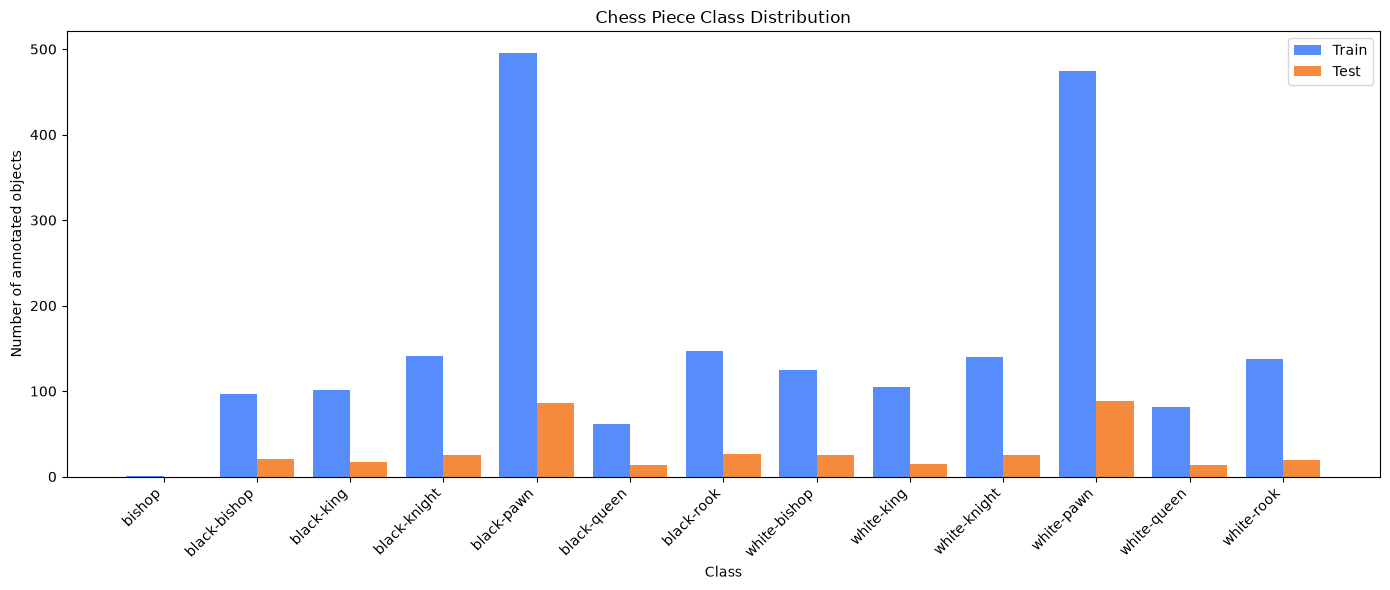

In [24]:
train_counts = [
    train_class_distribution.get(class_id, 0)
    for class_id in range(num_classes)
]

test_counts = [
    test_class_distribution.get(class_id, 0)
    for class_id in range(num_classes)
]

x = np.arange(num_classes)
width = 0.4

plt.figure(figsize=(14, 6))

plt.bar(x - width / 2, train_counts, width, label="Train")
plt.bar(x + width / 2, test_counts, width, label="Test")

plt.xticks(x, class_names, rotation=45, ha="right")
plt.ylabel("Number of annotated objects")
plt.xlabel("Class")
plt.title("Chess Piece Class Distribution")
plt.legend()

plt.tight_layout()
plt.show()

### Sample Visualization

A sample from the training dataset is visualized together with its corresponding YOLO annotations.

The normalized YOLO bounding-box coordinates are converted to pixel coordinates and overlaid on the original image.

This visualization provides a qualitative verification that the annotations are correctly aligned with the chess pieces and that the class mapping defined in `data.yaml` is interpreted correctly.


In [25]:
from PIL import Image, ImageDraw, ImageFont
import random


def visualize_sample(images_dir, labels_dir, class_names, image_index=None):
    """
    Display an image together with its YOLO bounding-box annotations.
    """

    images = sorted([
        path for path in images_dir.iterdir()
        if path.suffix.lower() in IMAGE_EXTENSIONS
    ])

    if not images:
        raise FileNotFoundError("No images found.")

    if image_index is None:
        image_index = random.randrange(len(images))

    image_path = images[image_index]
    label_path = labels_dir / f"{image_path.stem}.txt"

    image = Image.open(image_path).convert("RGB")

    width, height = image.size

    draw = ImageDraw.Draw(image)

    with open(label_path, "r") as file:
        annotations = file.readlines()

    for annotation in annotations:

        parts = annotation.strip().split()

        if len(parts) != 5:
            continue

        class_id = int(parts[0])
        x_center, y_center, box_width, box_height = map(float, parts[1:])

        # Convert normalized YOLO coordinates to pixel coordinates
        x_center *= width
        y_center *= height
        box_width *= width
        box_height *= height

        x_min = x_center - box_width / 2
        y_min = y_center - box_height / 2
        x_max = x_center + box_width / 2
        y_max = y_center + box_height / 2

        draw.rectangle(
            [x_min, y_min, x_max, y_max],
            outline="red",
            width=2
        )

        label = class_names[class_id]

        draw.text(
            (x_min, max(0, y_min - 15)),
            label,
            fill="red"
        )

    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Sample: {image_path.name}")
    plt.show()

    return image_path

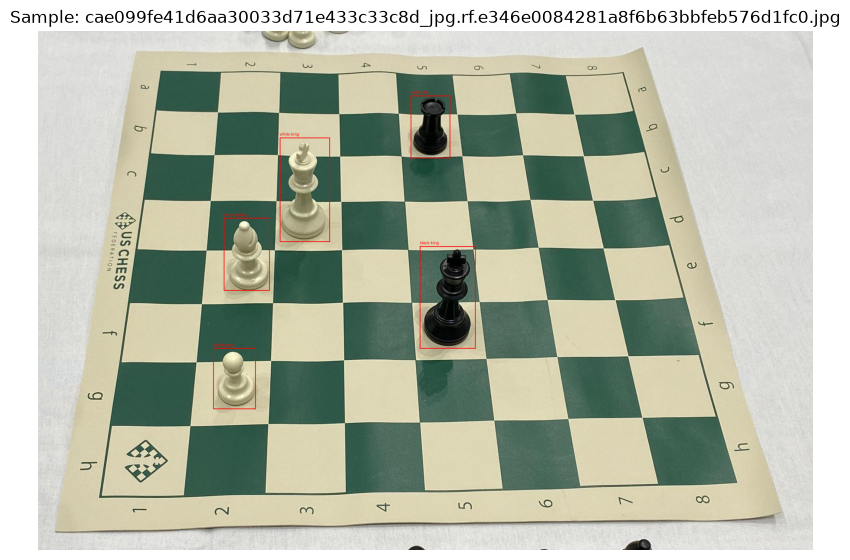

Displayed image: cae099fe41d6aa30033d71e433c33c8d_jpg.rf.e346e0084281a8f6b63bbfeb576d1fc0.jpg


In [26]:
sample_path = visualize_sample(
    TRAIN_IMAGES_DIR,
    TRAIN_LABELS_DIR,
    class_names
)

print(f"Displayed image: {sample_path.name}")

## Dataset Preparation

The dataset is prepared for YOLO11n fine-tuning while preserving the original test set for final evaluation.

The Roboflow export contains separate training and test splits but does not provide a validation split. Therefore, a validation subset is created from the training data.

The resulting dataset structure is:

```text
chess/
├── train/
│   ├── images/
│   └── labels/
├── valid/
│   ├── images/
│   └── labels/
├── test/
│   ├── images/
│   └── labels/
└── data.yaml
```

The test set is not modified or used during training. It is reserved exclusively for the final evaluation of the fine-tuned model.

A fixed random seed is used to make the train-validation split reproducible.


### Train-Validation Split

A fixed proportion of the original training set is allocated to validation.

A validation ratio of **20%** is used, resulting in approximately 80% of the original training images remaining in the training set and 20% being used for validation.

The split is performed at image level, and each image is moved together with its corresponding annotation file.


In [29]:
from sklearn.model_selection import train_test_split

VALIDATION_RATIO = 0.20
SEED = 42

train_image_paths = sorted([
    path for path in TRAIN_IMAGES_DIR.iterdir()
    if path.suffix.lower() in IMAGE_EXTENSIONS
])

train_paths, valid_paths = train_test_split(
    train_image_paths,
    test_size=VALIDATION_RATIO,
    random_state=SEED,
    shuffle=True
)

print("=" * 60)
print("Train-Validation Split")
print("=" * 60)

print(f"Original training images : {len(train_image_paths)}")
print(f"Training images          : {len(train_paths)}")
print(f"Validation images        : {len(valid_paths)}")
print(f"Validation ratio         : {VALIDATION_RATIO:.0%}")

Train-Validation Split
Original training images : 202
Training images          : 161
Validation images        : 41
Validation ratio         : 20%


In [30]:
import shutil

VALID_IMAGES_DIR = DATASET_DIR / "valid" / "images"
VALID_LABELS_DIR = DATASET_DIR / "valid" / "labels"

VALID_IMAGES_DIR.mkdir(parents=True, exist_ok=True)
VALID_LABELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Validation images directory: {VALID_IMAGES_DIR}")
print(f"Validation labels directory: {VALID_LABELS_DIR}")

Validation images directory: datasets/chess/valid/images
Validation labels directory: datasets/chess/valid/labels


In [31]:
for image_path in valid_paths:

    label_path = TRAIN_LABELS_DIR / f"{image_path.stem}.txt"

    if not label_path.exists():
        raise FileNotFoundError(
            f"Annotation not found for image: {image_path.name}"
        )

    shutil.move(
        str(image_path),
        str(VALID_IMAGES_DIR / image_path.name)
    )

    shutil.move(
        str(label_path),
        str(VALID_LABELS_DIR / label_path.name)
    )

print(f"Moved {len(valid_paths)} samples to validation set.")

Moved 41 samples to validation set.


In [32]:
train_images = [
    path for path in TRAIN_IMAGES_DIR.iterdir()
    if path.suffix.lower() in IMAGE_EXTENSIONS
]

valid_images = [
    path for path in VALID_IMAGES_DIR.iterdir()
    if path.suffix.lower() in IMAGE_EXTENSIONS
]

test_images = [
    path for path in TEST_IMAGES_DIR.iterdir()
    if path.suffix.lower() in IMAGE_EXTENSIONS
]

print("=" * 60)
print("Final Dataset Split")
print("=" * 60)

print(f"Train      : {len(train_images)} images")
print(f"Validation : {len(valid_images)} images")
print(f"Test       : {len(test_images)} images")

print(f"\nTotal      : {len(train_images) + len(valid_images) + len(test_images)} images")

Final Dataset Split
Train      : 161 images
Validation : 99 images
Test       : 29 images

Total      : 289 images


In [33]:
data_config["path"] = str(DATASET_DIR.resolve())
data_config["train"] = "train/images"
data_config["val"] = "valid/images"
data_config["test"] = "test/images"

with open(DATASET_DIR / "data.yaml", "w") as file:
    yaml.safe_dump(
        data_config,
        file,
        sort_keys=False
    )

print("data.yaml updated successfully.")

data.yaml updated successfully.


In [34]:
with open(DATASET_DIR / "data.yaml", "r") as file:
    updated_config = yaml.safe_load(file)

print("=" * 60)
print("Updated Dataset Configuration")
print("=" * 60)

for key, value in updated_config.items():
    print(f"{key}: {value}")

Updated Dataset Configuration
train: train/images
val: valid/images
test: test/images
nc: 13
names: ['bishop', 'black-bishop', 'black-king', 'black-knight', 'black-pawn', 'black-queen', 'black-rook', 'white-bishop', 'white-king', 'white-knight', 'white-pawn', 'white-queen', 'white-rook']
roboflow: {'workspace': 'joseph-nelson', 'project': 'chess-pieces-new', 'version': 23, 'license': 'Public Domain', 'url': 'https://universe.roboflow.com/joseph-nelson/chess-pieces-new/dataset/23'}
path: /tmp/pycharm_project_49c0ced5/datasets/chess


## Model Setup

The object detection model is initialized from the pretrained **YOLO11n** weights.

YOLO11n is the smallest model in the YOLO11 family and is selected because of its low computational and memory requirements, making it suitable for subsequent deployment on an embedded platform.

The pretrained weights are used as the initialization point for fine-tuning. The detection head is automatically adapted to the number of classes defined in the dataset configuration.

Before training, the model configuration and computational device are verified.


In [37]:
from ultralytics import YOLO

MODEL_NAME = "yolo11n.pt"

model = YOLO(MODEL_NAME)

print("=" * 60)
print("Model Setup")
print("=" * 60)

print(f"Model: {MODEL_NAME}")
print("Pretrained weights loaded successfully.")

Model Setup
Model: yolo11n.pt
Pretrained weights loaded successfully.


In [39]:
print("=" * 60)
print("Model Configuration")
print("=" * 60)

print(f"Number of classes: {model.model.nc}")

Model Configuration
Number of classes: 80


## Fine-Tuning

The pretrained YOLO11n model is fine-tuned on the prepared chess piece dataset. YOLO11 is a real-time object detection model designed to improve the balance between detection accuracy and computational efficiency through architectural enhancements to the YOLO framework [1].

Training is performed using the training split, while the validation split is used to monitor model performance during optimization. The test split remains completely isolated and is reserved for the final evaluation.

The training configuration is defined explicitly to ensure reproducibility and to provide control over the computational requirements of the experiment.

The training process also includes automatic model checkpointing and early stopping based on validation performance.

[1] R. Khanam and M. Hussain, *YOLOv11: An Overview of the Key Architectural Enhancements*, arXiv:2410.17725, 2024. [Paper](https://arxiv.org/abs/2410.17725)


### Training Configuration

The main training parameters are defined before starting the fine-tuning process.

The image size, batch size, number of epochs, validation patience, and number of data-loading workers are explicitly configured.

The computational device is selected automatically based on CUDA availability.


In [42]:
import torch

# Dataset
DATA_YAML = DATASET_DIR / "data.yaml"

# Training parameters
EPOCHS = 100
IMAGE_SIZE = 416
BATCH_SIZE = 16
PATIENCE = 20
WORKERS = 4

# Device
if torch.cuda.is_available():
    DEVICE = 0
    DEVICE_NAME = torch.cuda.get_device_name(0)
else:
    DEVICE = "cpu"
    DEVICE_NAME = "CPU"

print("=" * 60)
print("Fine-Tuning Configuration")
print("=" * 60)

print(f"Dataset      : {DATA_YAML.resolve()}")
print(f"Epochs       : {EPOCHS}")
print(f"Image size   : {IMAGE_SIZE}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Patience     : {PATIENCE}")
print(f"Workers      : {WORKERS}")
print(f"Device       : {DEVICE_NAME}")

Fine-Tuning Configuration
Dataset      : /tmp/pycharm_project_49c0ced5/datasets/chess/data.yaml
Epochs       : 100
Image size   : 416
Batch size   : 16
Patience     : 20
Workers      : 4
Device       : NVIDIA GeForce RTX 5090


### Start Fine-Tuning

The fine-tuning process is started from the pretrained YOLO11n weights.

The dataset configuration specifies the training, validation, and test splits. Validation metrics are monitored throughout training, and the best-performing checkpoint is preserved for subsequent evaluation.

Training results are stored in a dedicated experiment directory to keep the generated weights, metrics, plots, and configuration files organized.


In [ ]:
RESULTS_DIR = Path("runs/chess_yolo11n")

results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    patience=PATIENCE,
    workers=WORKERS,
    device=DEVICE,
    project=str(RESULTS_DIR.parent),
    name=RESULTS_DIR.name,
    pretrained=True,
    exist_ok=True
)

## Training Analysis

The training process generates several metrics and plots describing the optimization and validation performance of the model.

The training results are inspected to evaluate convergence, identify potential overfitting, and determine the best-performing checkpoint.

The analysis focuses on training and validation losses, detection metrics, and the evolution of model performance across epochs.


### Training Results

Ultralytics stores the training history in a `results.csv` file.

The file is loaded into a Pandas DataFrame to allow quantitative inspection of the training process.


In [48]:
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path(
    "/tmp/pycharm_project_49c0ced5/runs/detect/runs/chess_yolo11n"
)

RESULTS_CSV = RESULTS_DIR / "results.csv"

print(f"Results directory: {RESULTS_DIR}")
print(f"Results file: {RESULTS_CSV}")

training_results = pd.read_csv(RESULTS_CSV)

print("=" * 60)
print("Training Results")
print("=" * 60)

print(f"Number of epochs completed: {len(training_results)}")

training_results.tail()

Results directory: /tmp/pycharm_project_49c0ced5/runs/detect/runs/chess_yolo11n
Results file: /tmp/pycharm_project_49c0ced5/runs/detect/runs/chess_yolo11n/results.csv
Training Results
Number of epochs completed: 100


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
95,96,88.6436,0.79701,0.79088,0.83870,0.96895,0.97158,0.97352,0.78399,0.80244,0.54887,0.84505,0.000035,0.000035,0.000035
96,97,89.5197,0.74799,0.57419,0.83632,0.96921,0.97047,0.97326,0.78299,0.81725,0.55135,0.84776,0.000029,0.000029,0.000029
97,98,90.5602,0.72561,0.55684,0.83654,0.96547,0.97182,0.97296,0.78156,0.81569,0.54988,0.84737,0.000023,0.000023,0.000023
98,99,91.4972,0.71512,0.57117,0.82835,0.96539,0.97103,0.97294,0.78518,0.79080,0.54753,0.84263,0.000018,0.000018,0.000018
99,100,92.3950,0.73457,0.59835,0.83032,0.96429,0.97065,0.97271,0.78265,0.78134,0.54643,0.84050,0.000012,0.000012,0.000012


### Training Curves

The evolution of the training and validation losses is visualized to assess model convergence.

The classification, bounding-box regression, and distribution focal losses are inspected separately.


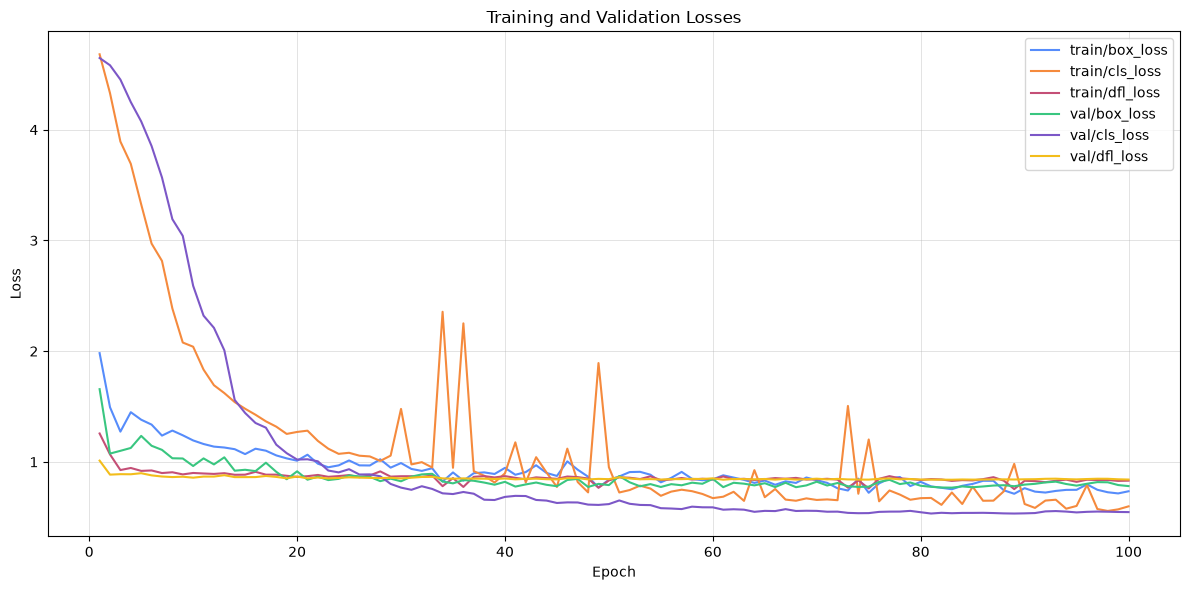

In [49]:
loss_columns = [
    "train/box_loss",
    "train/cls_loss",
    "train/dfl_loss",
    "val/box_loss",
    "val/cls_loss",
    "val/dfl_loss"
]

available_loss_columns = [
    column for column in loss_columns
    if column in training_results.columns
]

plt.figure(figsize=(12, 6))

for column in available_loss_columns:
    plt.plot(
        training_results["epoch"],
        training_results[column],
        label=column
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Losses")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Detection Metrics

The main object detection metrics recorded during validation are visualized across training epochs.

The analysis includes:

* Precision
* Recall
* mAP@50
* mAP@50-95

These metrics provide complementary information about detection quality and model generalization.


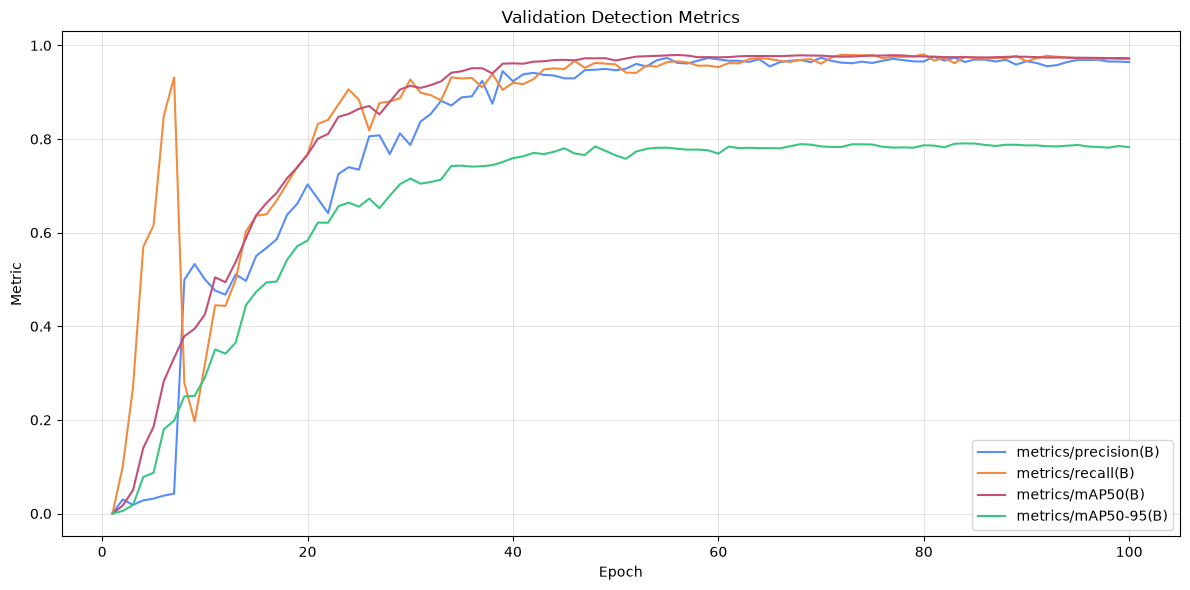

In [50]:
metric_columns = [
    "metrics/precision(B)",
    "metrics/recall(B)",
    "metrics/mAP50(B)",
    "metrics/mAP50-95(B)"
]

available_metric_columns = [
    column for column in metric_columns
    if column in training_results.columns
]

plt.figure(figsize=(12, 6))

for column in available_metric_columns:
    plt.plot(
        training_results["epoch"],
        training_results[column],
        label=column
    )

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Validation Detection Metrics")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Best Training Epoch

The epoch achieving the highest validation mAP@50-95 is identified from the training history.

This metric is used as the primary criterion because mAP@50-95 evaluates detection performance across multiple IoU thresholds and provides a stricter assessment than mAP@50.


In [51]:
MAP_COLUMN = "metrics/mAP50-95(B)"

if MAP_COLUMN in training_results.columns:

    best_index = training_results[MAP_COLUMN].idxmax()
    best_epoch = training_results.loc[best_index]

    print("=" * 60)
    print("Best Training Epoch")
    print("=" * 60)

    print(f"Epoch       : {int(best_epoch['epoch'])}")
    print(f"Precision   : {best_epoch['metrics/precision(B)']:.4f}")
    print(f"Recall      : {best_epoch['metrics/recall(B)']:.4f}")
    print(f"mAP@50      : {best_epoch['metrics/mAP50(B)']:.4f}")
    print(f"mAP@50-95   : {best_epoch[MAP_COLUMN]:.4f}")

Best Training Epoch
Epoch       : 84
Precision   : 0.9645
Recall      : 0.9755
mAP@50      : 0.9750
mAP@50-95   : 0.7907


## Test Set Evaluation

The best-performing YOLO11n checkpoint is evaluated on the independent test set.

The test set was not used during model optimization and was kept isolated throughout the fine-tuning process. Therefore, the resulting metrics provide an unbiased estimate of the model's detection performance on previously unseen data.

The evaluation includes overall detection metrics and class-wise performance analysis.


### Load Best Checkpoint

The checkpoint corresponding to the best validation performance is loaded for final evaluation.

The `best.pt` checkpoint is selected automatically from the training output directory.


In [52]:
BEST_MODEL_PATH = RESULTS_DIR / "weights" / "best.pt"

print("=" * 60)
print("Best Model")
print("=" * 60)

print(f"Checkpoint: {BEST_MODEL_PATH.resolve()}")
print(f"Exists    : {BEST_MODEL_PATH.exists()}")

assert BEST_MODEL_PATH.exists(), "Best model checkpoint not found."

best_model = YOLO(str(BEST_MODEL_PATH))

print("Best checkpoint loaded successfully.")

Best Model
Checkpoint: /tmp/pycharm_project_49c0ced5/runs/detect/runs/chess_yolo11n/weights/best.pt
Exists    : True
Best checkpoint loaded successfully.


### Test Set Evaluation

The trained model is evaluated using the test split specified in `data.yaml`.

The test evaluation uses the same image resolution employed during fine-tuning to ensure consistency between training and evaluation.


In [53]:
test_results = best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=IMAGE_SIZE,
    device=DEVICE,
    plots=True
)

Ultralytics 8.4.131 🚀 Python-3.12.3 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5090, 32111MiB)
YOLO11n summary (fused): 101 layers, 2,584,687 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 533.9±70.4 MB/s, size: 281.5 KB)
val: Scanning /tmp/pycharm_project_49c0ced5/datasets/chess/test/labels... 29 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 29/29 4.6Kit/s 0.0s
val: New cache created: /tmp/pycharm_project_49c0ced5/datasets/chess/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 5.5it/s 0.4s0.4s
                   all         29        376      0.968      0.978       0.98      0.819
          black-bishop         12         21      0.941          1      0.976      0.832
            black-king         17         17          1       0.98      0.995      0.855
          black-knight         15         25       0.96      0.967      0.993      0.822
            bla

### Overall Test Metrics

The main object detection metrics obtained on the test set are extracted and reported.

The evaluation focuses on Precision, Recall, mAP@50, and mAP@50-95.


In [55]:
test_metrics = test_results.results_dict

precision = test_metrics.get("metrics/precision(B)")
recall = test_metrics.get("metrics/recall(B)")
map50 = test_metrics.get("metrics/mAP50(B)")
map50_95 = test_metrics.get("metrics/mAP50-95(B)")

print("=" * 60)
print("Test Set Performance")
print("=" * 60)

print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"mAP@50      : {map50:.4f}")
print(f"mAP@50-95   : {map50_95:.4f}")

Test Set Performance
Precision   : 0.9679
Recall      : 0.9781
mAP@50      : 0.9804
mAP@50-95   : 0.8189


### Validation vs Test Performance

Validation and test metrics are compared to assess the generalization capability of the fine-tuned model.

A small difference between validation and test performance indicates consistent behavior on unseen data, whereas a substantial degradation on the test set may indicate overfitting or differences between the two data distributions.


In [56]:
validation_metrics = {
    "Precision": best_epoch["metrics/precision(B)"],
    "Recall": best_epoch["metrics/recall(B)"],
    "mAP@50": best_epoch["metrics/mAP50(B)"],
    "mAP@50-95": best_epoch["metrics/mAP50-95(B)"]
}

test_metrics_clean = {
    "Precision": precision,
    "Recall": recall,
    "mAP@50": map50,
    "mAP@50-95": map50_95
}

comparison = pd.DataFrame(
    {
        "Validation": validation_metrics,
        "Test": test_metrics_clean
    }
)

comparison["Difference"] = (
    comparison["Test"] - comparison["Validation"]
)

comparison

,Validation,Test,Difference
Precision,0.96447,0.967876,0.003406
Recall,0.97546,0.978142,0.002682
mAP@50,0.97496,0.980433,0.005473
mAP@50-95,0.79066,0.818919,0.028259


### Per-Class Performance

Detection performance is analyzed separately for each chess piece class.

Class-wise metrics provide additional information that cannot be obtained from the global mAP values alone and can reveal classes that are more difficult to detect.


In [57]:
class_metrics = test_results.box

print("=" * 60)
print("Per-Class Test Performance")
print("=" * 60)

for class_id, class_name in enumerate(class_names):

    if class_id < len(class_metrics.ap):

        print(
            f"{class_name:<15} | "
            f"Precision: {class_metrics.p[class_id]:.4f} | "
            f"Recall: {class_metrics.r[class_id]:.4f} | "
            f"mAP50: {class_metrics.ap50[class_id]:.4f} | "
            f"mAP50-95: {class_metrics.ap[class_id]:.4f}"
        )

Per-Class Test Performance
bishop          | Precision: 0.9414 | Recall: 1.0000 | mAP50: 0.9759 | mAP50-95: 0.8322
black-bishop    | Precision: 1.0000 | Recall: 0.9797 | mAP50: 0.9950 | mAP50-95: 0.8553
black-king      | Precision: 0.9603 | Recall: 0.9668 | mAP50: 0.9935 | mAP50-95: 0.8224
black-knight    | Precision: 0.9845 | Recall: 1.0000 | mAP50: 0.9839 | mAP50-95: 0.8039
black-pawn      | Precision: 0.9814 | Recall: 1.0000 | mAP50: 0.9950 | mAP50-95: 0.8098
black-queen     | Precision: 0.9938 | Recall: 1.0000 | mAP50: 0.9950 | mAP50-95: 0.8433
black-rook      | Precision: 0.9609 | Recall: 0.9841 | mAP50: 0.9919 | mAP50-95: 0.8189
white-bishop    | Precision: 0.9108 | Recall: 1.0000 | mAP50: 0.9744 | mAP50-95: 0.8410
white-king      | Precision: 0.9848 | Recall: 1.0000 | mAP50: 0.9950 | mAP50-95: 0.8746
white-knight    | Precision: 1.0000 | Recall: 0.9612 | mAP50: 0.9950 | mAP50-95: 0.7875
white-pawn      | Precision: 0.9885 | Recall: 0.8571 | mAP50: 0.9275 | mAP50-95: 0.7635
white

### Qualitative Evaluation

Several images from the test set are visualized together with their ground-truth annotations and YOLO11n predictions.

The comparison provides a qualitative assessment of the detector and helps identify correct detections, missed objects, false positives, classification errors, and inaccurate bounding-box localization.


In [71]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw


CONFIDENCE_THRESHOLD = 0.25


def visualize_test_samples(
    model,
    image_paths,
    labels_dir,
    class_names,
    confidence_threshold=0.25
):
    """
    Visualize multiple test samples with ground-truth
    and predicted bounding boxes.
    """

    for image_path in image_paths:

        image = Image.open(image_path).convert("RGB")
        width, height = image.size

        # --------------------------------------------------
        # Ground truth
        # --------------------------------------------------

        ground_truth = image.copy()
        gt_draw = ImageDraw.Draw(ground_truth)

        label_path = labels_dir / f"{image_path.stem}.txt"

        if label_path.exists():

            with open(label_path, "r") as file:
                annotations = file.readlines()

            for annotation in annotations:

                parts = annotation.strip().split()

                if len(parts) != 5:
                    continue

                class_id = int(parts[0])

                x_center, y_center, box_width, box_height = map(
                    float,
                    parts[1:]
                )

                x_center *= width
                y_center *= height
                box_width *= width
                box_height *= height

                x1 = x_center - box_width / 2
                y1 = y_center - box_height / 2
                x2 = x_center + box_width / 2
                y2 = y_center + box_height / 2

                gt_draw.rectangle(
                    [x1, y1, x2, y2],
                    outline="green",
                    width=2
                )

                gt_draw.text(
                    (x1, max(0, y1 - 15)),
                    class_names[class_id],
                    fill="green"
                )

        # --------------------------------------------------
        # Predictions
        # --------------------------------------------------

        predictions = image.copy()
        pred_draw = ImageDraw.Draw(predictions)

        results = model.predict(
            source=str(image_path),
            imgsz=IMAGE_SIZE,
            conf=confidence_threshold,
            device=DEVICE,
            verbose=False
        )

        result = results[0]

        if result.boxes is not None:

            boxes = result.boxes.xyxy.cpu().numpy()
            classes = result.boxes.cls.cpu().numpy().astype(int)
            confidences = result.boxes.conf.cpu().numpy()

            for box, class_id, confidence in zip(
                boxes,
                classes,
                confidences
            ):

                x1, y1, x2, y2 = box

                label = (
                    f"{class_names[class_id]} "
                    f"{confidence:.2f}"
                )

                pred_draw.rectangle(
                    [x1, y1, x2, y2],
                    outline="red",
                    width=2
                )

                pred_draw.text(
                    (x1, max(0, y1 - 15)),
                    label,
                    fill="red"
                )

        # --------------------------------------------------
        # Display
        # --------------------------------------------------

        plt.figure(figsize=(16, 7))

        plt.subplot(1, 2, 1)
        plt.imshow(ground_truth)
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(predictions)
        plt.title("YOLO11n Predictions")
        plt.axis("off")

        plt.suptitle(image_path.name)
        plt.tight_layout()
        plt.show()

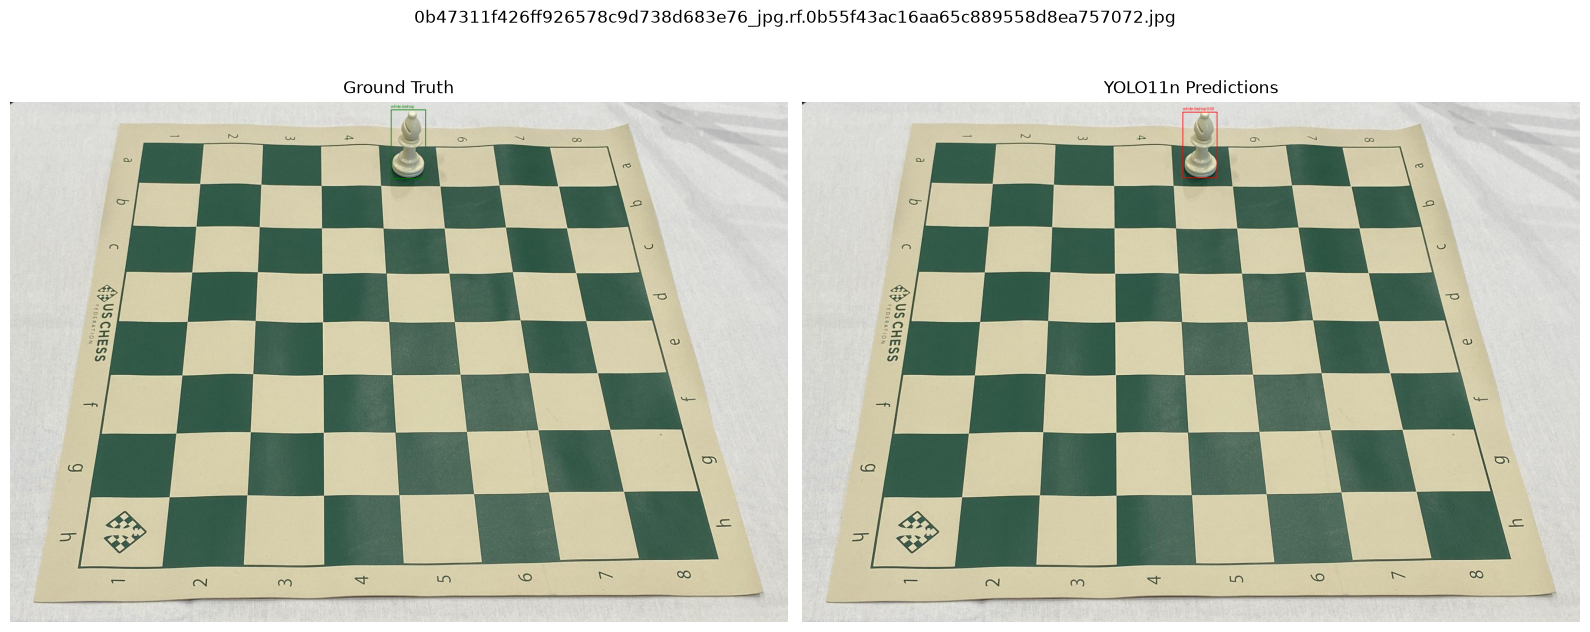

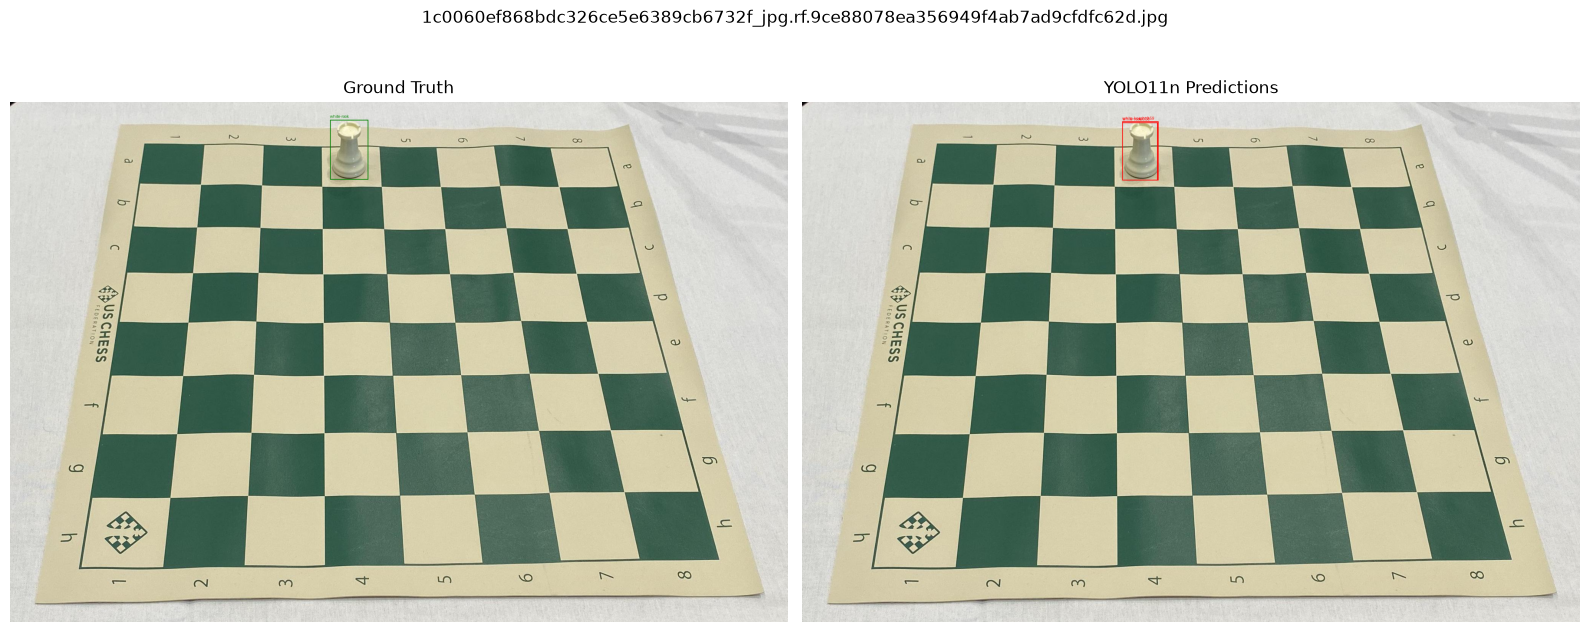

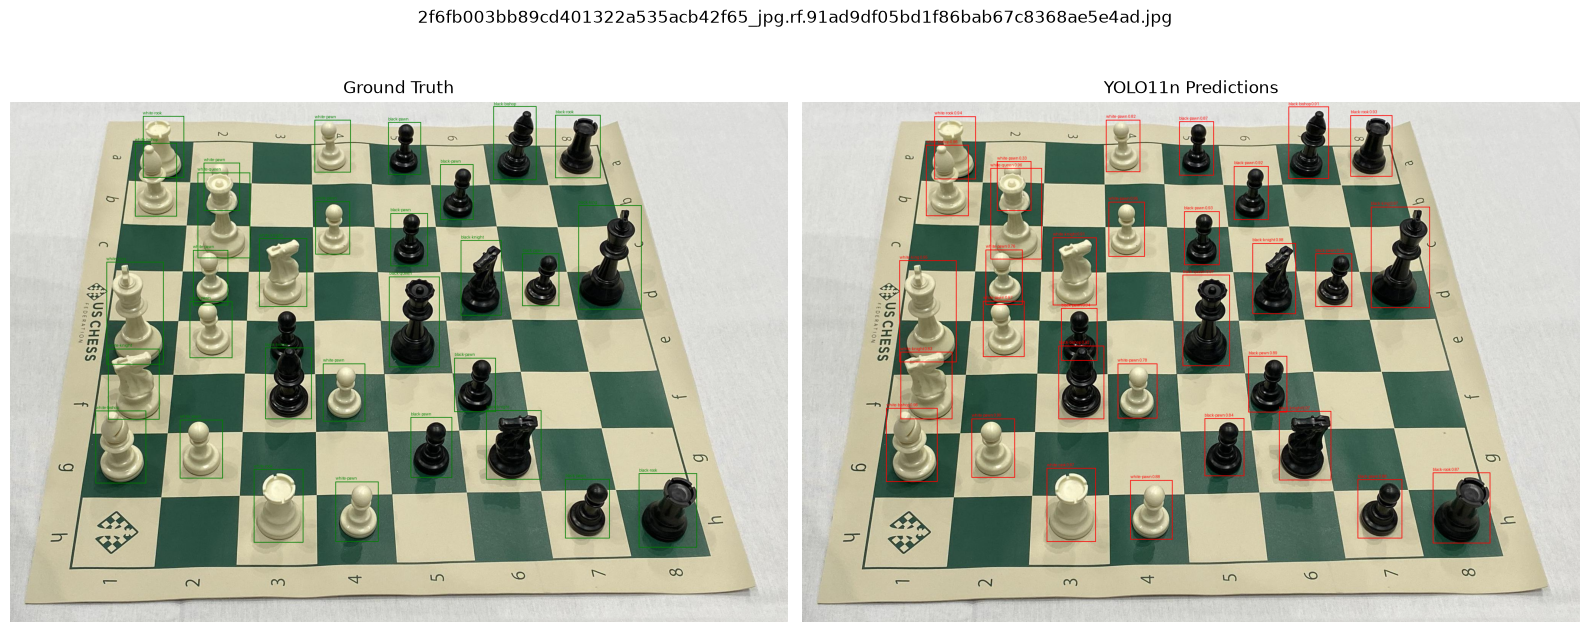

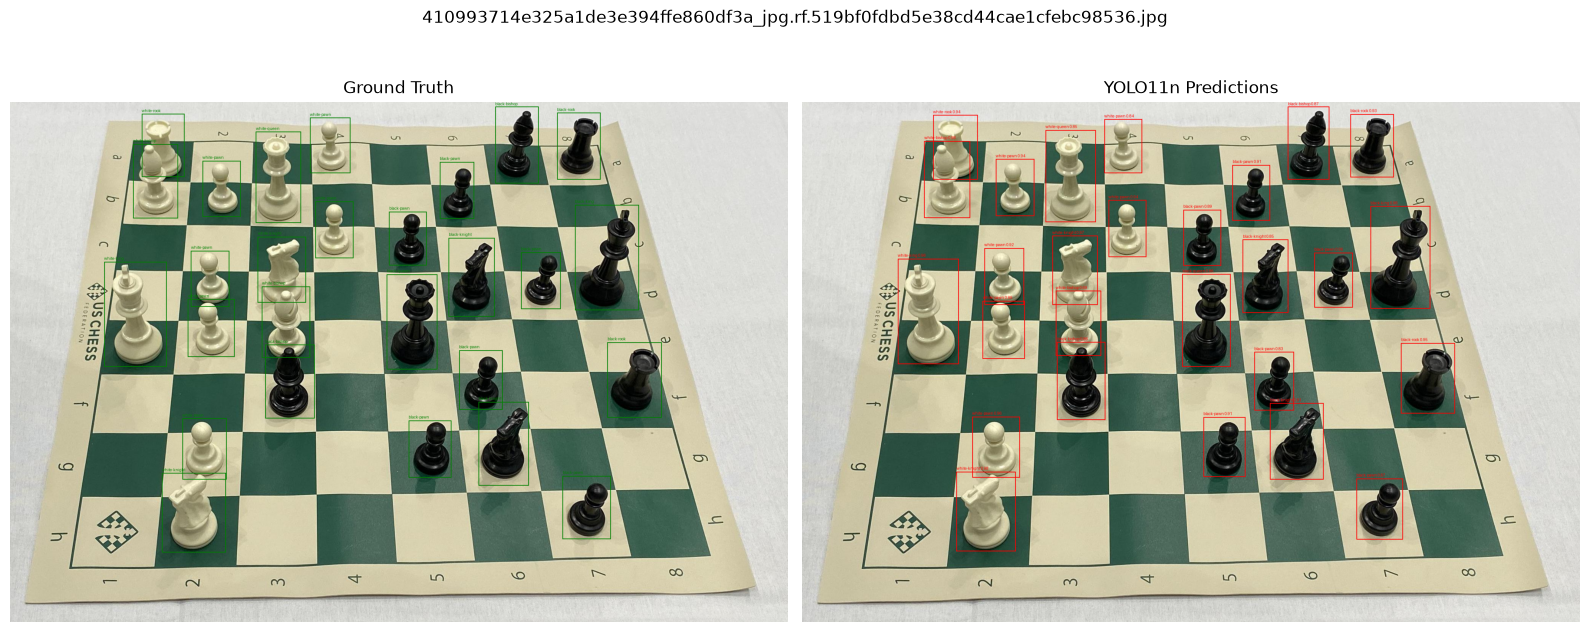

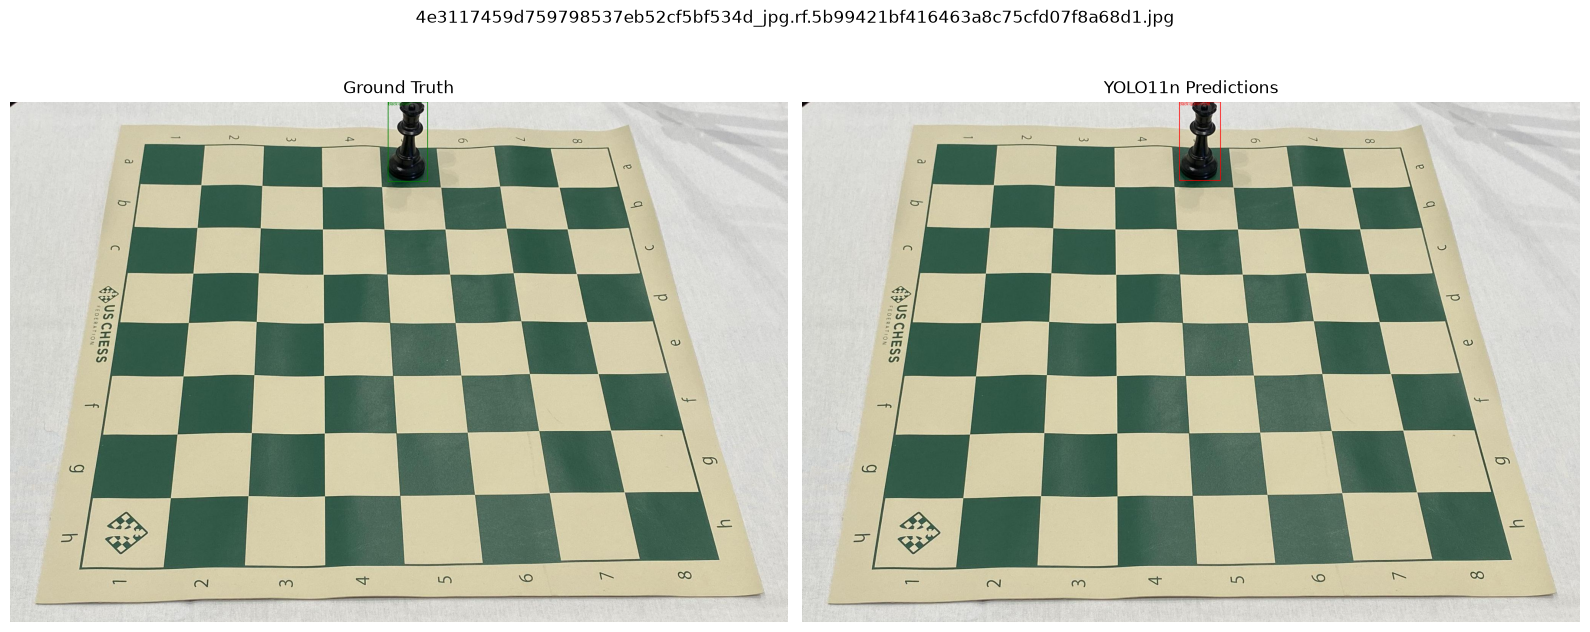

In [72]:
NUM_SAMPLES = 5

test_images = sorted([
    path for path in TEST_IMAGES_DIR.iterdir()
    if path.suffix.lower() in IMAGE_EXTENSIONS
])

selected_images = test_images[:NUM_SAMPLES]

visualize_test_samples(
    best_model,
    selected_images,
    TEST_LABELS_DIR,
    class_names,
    confidence_threshold=CONFIDENCE_THRESHOLD
)

## Model Export

The best-performing YOLO11n checkpoint is exported to the ONNX format for deployment on the target embedded platform.

ONNX provides a framework-independent representation of the trained neural network and allows the model to be executed using compatible inference runtimes.

The exported model uses the same input resolution adopted during fine-tuning. After export, the generated file is verified to ensure that the conversion was completed successfully.


### Export YOLO11n to ONNX

The best-performing checkpoint is exported from PyTorch format (`.pt`) to ONNX format (`.onnx`).

The exported model is configured for inference at the same image resolution used during fine-tuning.


In [73]:
EXPORT_PATH = best_model.export(
    format="onnx",
    imgsz=IMAGE_SIZE,
    dynamic=False
)

print("=" * 60)
print("ONNX Export")
print("=" * 60)

print(f"Exported model: {EXPORT_PATH}")

Ultralytics 8.4.131 🚀 Python-3.12.3 torch-2.13.0+cu130 CPU (AMD Ryzen 9 9900X 12-Core Processor)

PyTorch: starting from '/tmp/pycharm_project_49c0ced5/runs/detect/runs/chess_yolo11n/weights/best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 17, 3549) (5.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/19.1 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━ 11.5/19.1 MB 88.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━ 14.4/19.1 MB 39.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 46.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/23.1 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺ 22.8/23.1 MB 113.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 113.7 MB/s  0:00:00

   ━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━ 4/7 [onn

### Verify Exported Model

The generated ONNX file is checked for existence and file size.

A valid file is required before proceeding to ONNX inference and deployment benchmarking.


In [74]:
ONNX_PATH = Path(EXPORT_PATH)

assert ONNX_PATH.exists(), "ONNX model was not created."

onnx_size_mb = ONNX_PATH.stat().st_size / (1024 ** 2)

print("=" * 60)
print("ONNX Model")
print("=" * 60)

print(f"Path      : {ONNX_PATH.resolve()}")
print(f"Size      : {onnx_size_mb:.2f} MB")
print(f"Format    : {ONNX_PATH.suffix}")

ONNX Model
Path      : /tmp/pycharm_project_49c0ced5/runs/detect/runs/chess_yolo11n/weights/best.onnx
Size      : 10.03 MB
Format    : .onnx


## ONNX Evaluation

The exported ONNX model is evaluated to verify that it produces valid inference results after conversion from the original YOLO11n checkpoint.

The same test images are processed by both the PyTorch and ONNX versions of the model. Their predictions are compared to verify that the export preserves the original model behavior.


### Load ONNX Model

The exported ONNX model is loaded through the Ultralytics interface.

This allows the same prediction API used with the PyTorch checkpoint to be applied to the exported model.


In [76]:
onnx_model = YOLO(str(ONNX_PATH))

print("=" * 60)
print("ONNX Model Loading")
print("=" * 60)

print(f"Model: {ONNX_PATH.resolve()}")
print("ONNX model loaded successfully.")

ONNX Model Loading
Model: /tmp/pycharm_project_49c0ced5/runs/detect/runs/chess_yolo11n/weights/best.onnx
ONNX model loaded successfully.


### ONNX Inference

A sample from the test set is processed using the exported ONNX model.

The predicted bounding boxes, class labels, and confidence scores are visualized to verify that the exported model performs valid object detection.


In [77]:
onnx_result = onnx_model.predict(
    source=str(sample_test_image),
    imgsz=IMAGE_SIZE,
    conf=CONFIDENCE_THRESHOLD,
    verbose=False
)[0]

onnx_result

Loading /tmp/pycharm_project_49c0ced5/runs/detect/runs/chess_yolo11n/weights/best.onnx for ONNX Runtime inference...
requirements: Ultralytics requirement ['onnxruntime-gpu'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/202.2 MB ? eta -:--:--
   ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/202.2 MB 26.2 MB/s eta 0:00:08
   ━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/202.2 MB 57.7 MB/s eta 0:00:04
   ━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/202.2 MB 73.4 MB/s eta 0:00:03
   ━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/202.2 MB 84.1 MB/s eta 0:00:02
   ━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━ 86.5/202.2 MB 88.7 MB/s eta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━ 109.3/202.2 MB 92.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━ 129.8/202.2 MB 94.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━ 151.8/202.2 MB 96.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━ 155.2/202.2 MB 96.6 MB/s eta 0:0

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
depth: None
keypoints: None
masks: None
names: {0: 'bishop', 1: 'black-bishop', 2: 'black-king', 3: 'black-knight', 4: 'black-pawn', 5: 'black-queen', 6: 'black-rook', 7: 'white-bishop', 8: 'white-king', 9: 'white-knight', 10: 'white-pawn', 11: 'white-queen', 12: 'white-rook'}
obb: None
orig_img: array([[[  4,   4,   4],
        [  3,   3,   3],
        [  6,   6,   6],
        ...,
        [216, 218, 218],
        [216, 218, 218],
        [216, 218, 218]],

       [[  6,   6,   6],
        [  7,   7,   7],
        [ 11,  11,  11],
        ...,
        [215, 217, 217],
        [217, 219, 219],
        [218, 220, 220]],

       [[  7,   7,   7],
        [  8,   8,   8],
        [ 14,  14,  14],
        ...,
        [214, 216, 216],
        [217, 219, 219],
        [218, 220, 220]],

       ...,

       [[194, 199, 198],
        [202, 207, 206],
        [203, 208, 207],
        ...,

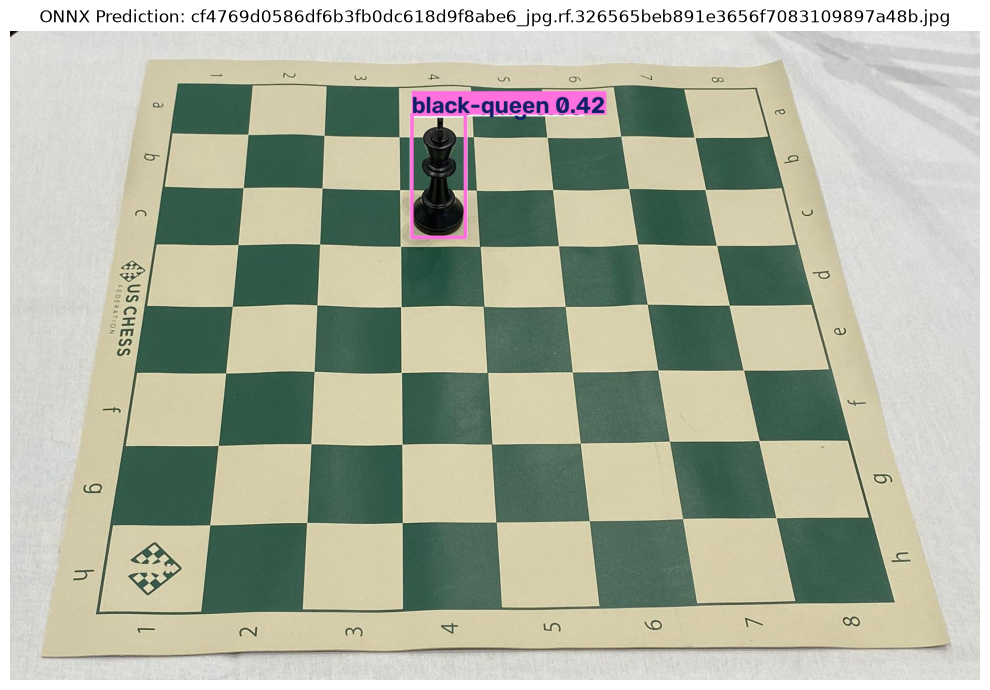

In [78]:
annotated_image = onnx_result.plot()

plt.figure(figsize=(10, 8))
plt.imshow(annotated_image[..., ::-1])
plt.axis("off")
plt.title(f"ONNX Prediction: {sample_test_image.name}")
plt.tight_layout()
plt.show()

### PyTorch vs ONNX Comparison

The same test image is processed using both the original PyTorch checkpoint and the exported ONNX model.

The resulting detections are visualized side by side to verify that the conversion does not introduce significant differences in the predicted classes, confidence scores, or bounding-box locations.


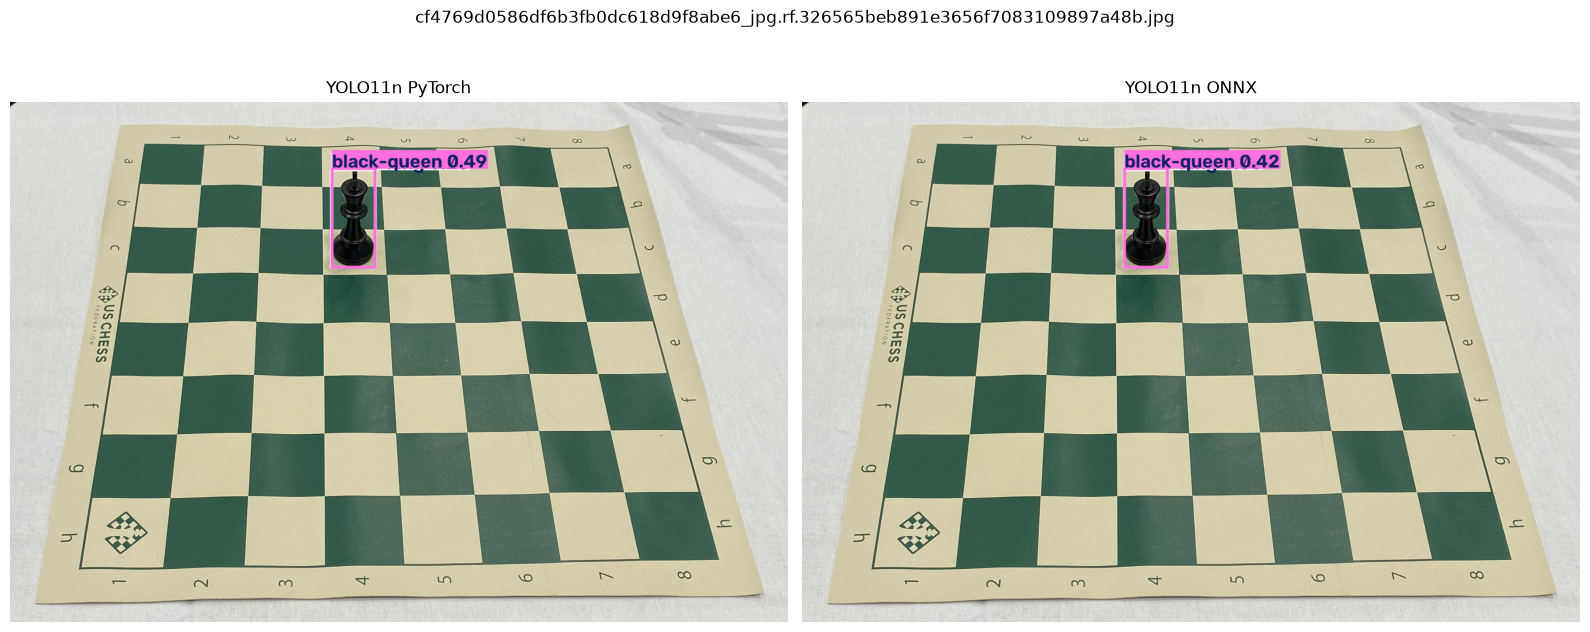

In [79]:
pytorch_result = best_model.predict(
    source=str(sample_test_image),
    imgsz=IMAGE_SIZE,
    conf=CONFIDENCE_THRESHOLD,
    device=DEVICE,
    verbose=False
)[0]

onnx_result = onnx_model.predict(
    source=str(sample_test_image),
    imgsz=IMAGE_SIZE,
    conf=CONFIDENCE_THRESHOLD,
    verbose=False
)[0]

pytorch_image = pytorch_result.plot()
onnx_image = onnx_result.plot()

plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
plt.imshow(pytorch_image[..., ::-1])
plt.title("YOLO11n PyTorch")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(onnx_image[..., ::-1])
plt.title("YOLO11n ONNX")
plt.axis("off")

plt.suptitle(sample_test_image.name)
plt.tight_layout()
plt.show()

##  Model Benchmark

The computational characteristics of the fine-tuned model are measured to assess its suitability for deployment on an embedded platform.

The benchmark compares the original PyTorch checkpoint and the exported ONNX model in terms of model size and inference latency.

Inference latency is measured over multiple test images after a warm-up phase. The average inference time and corresponding FPS are reported for both model formats.

The benchmark is performed on the current computational environment. The results therefore provide a reference for comparison with the final deployment benchmark on the target embedded platform.


### Model Size

The file size of the PyTorch and ONNX models is measured and compared.

Model size is relevant for embedded deployment because it affects storage requirements and can also influence memory usage during inference.


In [81]:
PYTORCH_PATH = BEST_MODEL_PATH
ONNX_PATH = Path(EXPORT_PATH)

pytorch_size_mb = PYTORCH_PATH.stat().st_size / (1024 ** 2)
onnx_size_mb = ONNX_PATH.stat().st_size / (1024 ** 2)

print("=" * 60)
print("Model Size")
print("=" * 60)

print(f"PyTorch (.pt) : {pytorch_size_mb:.2f} MB")
print(f"ONNX (.onnx)  : {onnx_size_mb:.2f} MB")

Model Size
PyTorch (.pt) : 5.19 MB
ONNX (.onnx)  : 10.03 MB


### Inference Benchmark

Inference latency is measured using images from the test set.

A warm-up phase is performed before collecting measurements in order to reduce the influence of model initialization, memory allocation, and runtime startup overhead.

The average inference latency and corresponding frames per second (FPS) are calculated for both the PyTorch and ONNX models.


In [82]:
import time
import numpy as np


NUM_WARMUP = 5
NUM_BENCHMARK_IMAGES = min(20, len(test_images))

benchmark_images = test_images[:NUM_BENCHMARK_IMAGES]

print("=" * 60)
print("Benchmark Configuration")
print("=" * 60)

print(f"Warm-up iterations : {NUM_WARMUP}")
print(f"Benchmark images   : {NUM_BENCHMARK_IMAGES}")

Benchmark Configuration
Warm-up iterations : 5
Benchmark images   : 20


In [83]:
# Warm-up
for image_path in benchmark_images[:NUM_WARMUP]:

    best_model.predict(
        source=str(image_path),
        imgsz=IMAGE_SIZE,
        device=DEVICE,
        verbose=False
    )


# Benchmark
pytorch_times = []

for image_path in benchmark_images:

    start_time = time.perf_counter()

    best_model.predict(
        source=str(image_path),
        imgsz=IMAGE_SIZE,
        device=DEVICE,
        verbose=False
    )

    end_time = time.perf_counter()

    pytorch_times.append(end_time - start_time)


pytorch_avg_time = np.mean(pytorch_times)
pytorch_fps = 1 / pytorch_avg_time

print("=" * 60)
print("PyTorch Benchmark")
print("=" * 60)

print(f"Average inference time : {pytorch_avg_time * 1000:.2f} ms")
print(f"Average FPS            : {pytorch_fps:.2f}")

PyTorch Benchmark
Average inference time : 9.57 ms
Average FPS            : 104.44


In [84]:
# Warm-up
for image_path in benchmark_images[:NUM_WARMUP]:

    onnx_model.predict(
        source=str(image_path),
        imgsz=IMAGE_SIZE,
        verbose=False
    )


# Benchmark
onnx_times = []

for image_path in benchmark_images:

    start_time = time.perf_counter()

    onnx_model.predict(
        source=str(image_path),
        imgsz=IMAGE_SIZE,
        verbose=False
    )

    end_time = time.perf_counter()

    onnx_times.append(end_time - start_time)


onnx_avg_time = np.mean(onnx_times)
onnx_fps = 1 / onnx_avg_time

print("=" * 60)
print("ONNX Benchmark")
print("=" * 60)

print(f"Average inference time : {onnx_avg_time * 1000:.2f} ms")
print(f"Average FPS            : {onnx_fps:.2f}")

ONNX Benchmark
Average inference time : 47.77 ms
Average FPS            : 20.93


### Benchmark Comparison

The measured model size and inference performance are summarized to facilitate comparison between the PyTorch and ONNX formats.

Inference measurements include the complete prediction call and therefore represent end-to-end inference time within the current software environment.


In [85]:
benchmark_results = pd.DataFrame(
    {
        "Model": [
            "YOLO11n PyTorch",
            "YOLO11n ONNX"
        ],
        "Size (MB)": [
            pytorch_size_mb,
            onnx_size_mb
        ],
        "Average Inference (ms)": [
            pytorch_avg_time * 1000,
            onnx_avg_time * 1000
        ],
        "FPS": [
            pytorch_fps,
            onnx_fps
        ]
    }
)

benchmark_results

,Model,Size (MB),Average Inference (ms),FPS
0,YOLO11n PyTorch,5.193201,9.574932,104.439380
1,YOLO11n ONNX,10.029415,47.772220,20.932668


The benchmark shows that the PyTorch model provides substantially lower inference latency in the current environment, while the ONNX model provides a deployment-oriented, framework-independent representation. These measurements serve as a reference baseline, as the final inference performance will depend on the runtime and hardware used on the target embedded platform.


## Model Artifacts and Deployment Summary

The final artifacts produced throughout the training and export pipeline are summarized below.

The fine-tuned YOLO11n model is available in both PyTorch and ONNX formats. The ONNX model provides a framework-independent representation suitable for deployment on compatible embedded inference runtimes.

The reported benchmark results were obtained in the current development environment and should be considered a reference baseline. Final deployment performance must be measured directly on the target hardware.


### Final Model Summary

The main characteristics and validation performance of the final fine-tuned model are summarized below.


In [86]:
print("=" * 60)
print("Final Model Summary")
print("=" * 60)

print(f"Model              : YOLO11n")
print(f"Number of classes  : {len(class_names)}")
print(f"Input resolution   : {IMAGE_SIZE} x {IMAGE_SIZE}")
print(f"Best epoch         : {best_epoch['epoch']}")

print("\nValidation Performance")
print(f"Precision           : {best_epoch['metrics/precision(B)']:.4f}")
print(f"Recall              : {best_epoch['metrics/recall(B)']:.4f}")
print(f"mAP@50              : {best_epoch['metrics/mAP50(B)']:.4f}")
print(f"mAP@50-95           : {best_epoch['metrics/mAP50-95(B)']:.4f}")

Final Model Summary
Model              : YOLO11n
Number of classes  : 13
Input resolution   : 416 x 416
Best epoch         : 84.0

Validation Performance
Precision           : 0.9645
Recall              : 0.9755
mAP@50              : 0.9750
mAP@50-95           : 0.7907


### Model Artifacts

The main model artifacts generated by the pipeline are listed below.

The PyTorch checkpoint is retained as the primary training artifact, while the ONNX model is intended for deployment and inference using a compatible runtime.


In [87]:
print("=" * 60)
print("Model Artifacts")
print("=" * 60)

print(f"PyTorch model : {PYTORCH_PATH.resolve()}")
print(f"ONNX model   : {ONNX_PATH.resolve()}")

print("\nModel Sizes")
print(f"PyTorch : {pytorch_size_mb:.2f} MB")
print(f"ONNX   : {onnx_size_mb:.2f} MB")

Model Artifacts
PyTorch model : /tmp/pycharm_project_49c0ced5/runs/detect/runs/chess_yolo11n/weights/best.pt
ONNX model   : /tmp/pycharm_project_49c0ced5/runs/detect/runs/chess_yolo11n/weights/best.onnx

Model Sizes
PyTorch : 5.19 MB
ONNX   : 10.03 MB


###  Benchmark Summary

The reference inference benchmark obtained in the development environment is summarized below.

The PyTorch implementation achieved lower latency in the current environment, while the ONNX model provides the format intended for the subsequent embedded deployment stage.


In [88]:
benchmark_results

,Model,Size (MB),Average Inference (ms),FPS
0,YOLO11n PyTorch,5.193201,9.574932,104.439380
1,YOLO11n ONNX,10.029415,47.772220,20.932668


### Deployment Target

The exported ONNX model is intended for deployment on the Arduino UNO Q.

The final deployment stage consists of transferring the exported model to the target platform, configuring the corresponding inference runtime, and measuring inference latency and throughput directly on the embedded hardware.

The benchmark obtained during this notebook execution is therefore considered a development baseline rather than a measurement of the target platform's performance.
